# Real Waste / Litter Detection with Faster R-CNN — TACO Dataset


Dataset: **TACO — Trash Annotations in Context** (Proença & Simões, 2020). ~1500 photos of litter
in the wild (roads, beaches, woods), annotated in COCO format with 60 fine-grained litter
categories grouped into 28 broader "supercategories." Images are hosted on Flickr; this notebook
downloads them directly from the dataset's public annotation file.

---

## Architecture flow — the big picture before we touch any code

Think of the whole pipeline as four stages, each handing its output to the next:

**Stage 1 — Data.** A COCO-format JSON file lists every image plus every litter object in it as
`(image_id, category, box)`. TACO's 60 categories are heavily imbalanced (a few hundred cigarette
butts, only a handful of some other class), so — following the same reduction TACO's own paper
uses ("TACO-10") — we keep the **9 most common supercategories** and dump everything rarer into a
10th bucket, `"Other Litter"`. This keeps the model from wasting capacity on categories with too
few examples to learn anything from.

**Stage 2 — Model (Faster R-CNN, ResNet50-FPN-v2).** One forward pass has three parts, and it
helps to think of them as three people looking at the photo in turn:
- **Backbone + FPN** — a generalist who scans the whole photo at several zoom levels at once
  (coarse "there's clutter in that corner" down to fine "that's a bottle cap edge"), producing a
  stack of feature maps.
- **RPN (Region Proposal Network)** — a *scout*. It slides over those feature maps and says
  "something object-shaped might be here" for a few hundred candidate boxes, without yet saying
  *what* — just *where*.
- **ROI heads** — the *expert*. For each of the scout's candidate boxes, ROIAlign crops out that
  patch of feature map, and two small networks look at just that patch: one refines the box
  edges, the other says which of our 10 waste classes (or "none of them, this was a false alarm")
  it is.

This is the fundamental difference from the earlier project: there, one softmax spoke for the
*whole image*. Here, the RPN first finds *how many* things to even look at, and the classifier
speaks once per candidate box — real multi-object detection.

**Stage 3 — Training.** Faster R-CNN's loss is the sum of four pieces, two from the scout and two
from the expert: RPN classification loss (is there an object here or not), RPN box-regression
loss (how far off is the scout's rough box), ROI classification loss (which of the 10 classes),
ROI box-regression loss (fine-tune the expert's box). We don't need to touch these individually —
`model(images, targets)` returns all four already summed per component; we just add them and
backpropagate.

**Stage 4 — Inference & evaluation.** At test time there are no targets — the model returns its
own best guess: a list of boxes, each with a class label and a confidence score, already filtered
by non-max suppression (duplicate boxes for the same object are merged) and a score threshold.
We score these predictions against the ground truth using **COCO mAP** — the standard detection
metric — rather than plain accuracy, because "did we find the right *number* of objects, in the
right *places*" is a different question from "did we assign the right label," and mAP captures
both.

Every cell below is preceded by a short note on **what** it does and **why** it's needed at that
point in the flow above.

### Cell: install / upgrade libraries
**What:** installs the packages this notebook needs beyond Colab's defaults: an up-to-date
`torch`/`torchvision` (recent enough for `fasterrcnn_resnet50_fpn_v2` and the `transforms.v2` +
`tv_tensors` API, which is what lets bounding boxes get resized/flipped automatically together
with the image), `pycocotools` (reads/writes COCO-format annotations and computes mAP), and
`requests`/`tqdm` for downloading the dataset with a progress bar.
**Why here:** installs must run before any `import` that depends on them.

In [1]:
!pip install -q --upgrade torch torchvision pycocotools requests tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/5

In [2]:
import os, io, json, random, time, copy
from collections import Counter

import requests
from tqdm.auto import tqdm
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import torchvision
from torchvision import tv_tensors
from torchvision.transforms import v2
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.utils import draw_bounding_boxes

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


### Cell: configuration
**What:** one place for every path/hyperparameter used later — image folder, resize size, batch
size, epoch count, learning rate, and how many of TACO's supercategories to keep before bucketing
the rest into "Other Litter."
**Why here:** keeping these together means re-running the whole notebook with a different
resize resolution or a different number of kept categories is a one-line change, not a hunt
through every cell.

In [3]:
IMG_DIR = "/content/taco_images"          # where downloaded photos are cached
ANN_PATH = "/content/taco_annotations.json"  # the COCO-format annotation file
os.makedirs(IMG_DIR, exist_ok=True)

TOP_K_SUPERCATEGORIES = 9   # kept as their own class; everything else -> "Other Litter"
                             # (this mirrors the "TACO-10" reduction used in the TACO paper itself)
IMG_SIZE = 512               # Faster R-CNN handles rectangular images fine, but a fixed square
                             # size keeps batching simple and memory use predictable on a Colab GPU
BATCH_SIZE = 4
NUM_EPOCHS = 12
LR = 0.005
SCORE_THRESH_INFERENCE = 0.5   # confidence floor used only when *displaying* predictions

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


### Cell: fetch TACO's annotation file
**What:** downloads the single COCO-format JSON that describes every TACO image and every
litter box in it, straight from the dataset's public GitHub repo.
**Why here:** this file is the map for everything that follows — we need it before we can decide
*which* images to download or *how* to group their 60 categories down to a workable number.

In [4]:
TACO_ANNOTATIONS_URL = (
    "https://raw.githubusercontent.com/pedropro/TACO/master/data/annotations.json"
)

if not os.path.exists(ANN_PATH):
    print("Downloading TACO annotations...")
    r = requests.get(TACO_ANNOTATIONS_URL, timeout=60)
    r.raise_for_status()
    with open(ANN_PATH, "wb") as f:
        f.write(r.content)

with open(ANN_PATH) as f:
    taco_json = json.load(f)

print(f"{len(taco_json['images'])} images, {len(taco_json['annotations'])} annotations, "
      f"{len(taco_json['categories'])} fine-grained categories")


1500 images, 4784 annotations, 60 fine-grained categories


### Cell: download the actual photos
**What:** for every image entry in the annotation file, downloads the Flickr-hosted photo (the
smaller `flickr_640_url` version — plenty of resolution once we resize to `IMG_SIZE` anyway, and
much faster than the full-resolution originals) into `IMG_DIR`, named by its COCO `image_id`.
**Why here:** TACO ships annotations only — the images themselves live on Flickr and have to be
fetched separately. Some links inevitably rot over time (a photo gets deleted, an account goes
private); this cell skips those with a warning instead of stopping the whole notebook, and keeps
a list of which image ids actually downloaded successfully, since only those can be used for
training/evaluation.
**Heads-up:** this downloads ~1500 images and can take 10-20 minutes on Colab's network — it only
needs to run once per session; re-running skips files that already exist.

In [5]:
def download_taco_images(images_meta, img_dir):
    downloaded_ids = []
    for img in tqdm(images_meta, desc="Downloading TACO images"):
        img_id = img["id"]
        dest = os.path.join(img_dir, f"{img_id}.jpg")
        if os.path.exists(dest):
            downloaded_ids.append(img_id)
            continue
        url = img.get("flickr_640_url") or img.get("flickr_url")
        try:
            resp = requests.get(url, timeout=15)
            resp.raise_for_status()
            with open(dest, "wb") as f:
                f.write(resp.content)
            downloaded_ids.append(img_id)
        except Exception as e:
            print(f"  skipped image {img_id}: {e}")
    return downloaded_ids


downloaded_ids = download_taco_images(taco_json["images"], IMG_DIR)
print(f"Successfully downloaded {len(downloaded_ids)} / {len(taco_json['images'])} images")


  skipped image 1457: 502 Server Error: Bad Gateway for url: https://farm66.staticflickr.com/65535/48661146521_ea8f9df2ec_z.jpg
  skipped image 1458: 502 Server Error: Bad Gateway for url: https://farm66.staticflickr.com/65535/48661146486_c52afc1e85_z.jpg
  skipped image 1459: 502 Server Error: Bad Gateway for url: https://farm66.staticflickr.com/65535/48661146411_0bae818aae_z.jpg
  skipped image 1460: 502 Server Error: Bad Gateway for url: https://farm66.staticflickr.com/65535/48661293432_9086fe26e9_z.jpg
  skipped image 1461: 502 Server Error: Bad Gateway for url: https://farm66.staticflickr.com/65535/48661145926_c2eb8c2a93_z.jpg
  skipped image 1462: 502 Server Error: Bad Gateway for url: https://farm66.staticflickr.com/65535/48660791058_95ebb843dd_z.jpg
  skipped image 1463: 502 Server Error: Bad Gateway for url: https://farm66.staticflickr.com/65535/48661145516_3776efa0c3_z.jpg
  skipped image 1464: 502 Server Error: Bad Gateway for url: https://farm66.staticflickr.com/65535/48661

### Cell: load the annotations into pycocotools, look at what we actually have
**What:** wraps the JSON in a `pycocotools.COCO` object, which gives fast lookups like "all
annotations for image X" or "all categories" without us writing that indexing code by hand. Then
prints the most common categories, so the reduction decision in the next cell is based on real
numbers rather than a guess.
**Why here:** every later cell (dataset class, evaluation) leans on this `coco` object's lookup
methods (`getAnnIds`, `loadAnns`, `loadCats`, ...) — it's the shared index for the rest of the
notebook.

In [6]:
coco = COCO(ANN_PATH)

cats = coco.loadCats(coco.getCatIds())
supercat_counts = Counter()
for img_id in downloaded_ids:
    for a in coco.loadAnns(coco.getAnnIds(imgIds=img_id)):
        cat = coco.loadCats(a["category_id"])[0]
        supercat_counts[cat["supercategory"]] += 1

print("Annotation count by supercategory (downloaded images only):")
for sc, n in supercat_counts.most_common():
    print(f"  {sc:25s} {n}")


loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Annotation count by supercategory (downloaded images only):
  Plastic bag & wrapper     824
  Cigarette                 638
  Unlabeled litter          496
  Bottle                    415
  Bottle cap                278
  Can                       270
  Other plastic             270
  Carton                    239
  Cup                       189
  Straw                     159
  Paper                     139
  Broken glass              138
  Styrofoam piece           111
  Pop tab                   99
  Lid                       84
  Plastic container         72
  Aluminium foil            59
  Plastic utensils          37
  Rope & strings            28
  Paper bag                 27
  Scrap metal               18
  Food waste                8
  Squeezable tube           7
  Shoe                      7
  Blister pack              7
  Glass jar                 6
  Plastic glooves           4
  Battery    

### Cell: reduce 28 supercategories down to a trainable class set
**What:** keeps the `TOP_K_SUPERCATEGORIES` most frequent supercategories as their own classes,
and maps every other (rare) supercategory to a single `"Other Litter"` class. Builds
`cat_id_to_label`, a dictionary from TACO's original fine-grained category id straight to our new,
small label id (with `0` reserved for "background," as Faster R-CNN's classifier expects).
**Why here:** with only ~1500 images spread across 60 original categories, most categories would
have single-digit example counts — nowhere near enough to learn a reliable detector for each one.
Grouping into ~10 classes concentrates the (still limited) data into categories the model has a
realistic chance of learning, which is exactly the trade-off TACO's own authors made when
reporting results.

In [7]:
top_supercats = [sc for sc, _ in supercat_counts.most_common(TOP_K_SUPERCATEGORIES)]
CLASSES = top_supercats + ["Other Litter"]
NUM_CLASSES = len(CLASSES) + 1   # +1 for Faster R-CNN's background class

cat_id_to_label = {}
for c in cats:
    sc = c["supercategory"]
    class_name = sc if sc in top_supercats else "Other Litter"
    cat_id_to_label[c["id"]] = CLASSES.index(class_name) + 1   # 0 is background

print("Classes (label id : name):")
for i, c in enumerate(CLASSES, start=1):
    print(f"  {i}: {c}")


Classes (label id : name):
  1: Plastic bag & wrapper
  2: Cigarette
  3: Unlabeled litter
  4: Bottle
  5: Bottle cap
  6: Can
  7: Other plastic
  8: Carton
  9: Cup
  10: Other Litter


### Cell: train / val / test split
**What:** shuffles the successfully-downloaded image ids and splits them 80/10/10.
**Why here:** the split has to happen at the *image* level (not the annotation level) — an image
with three litter items must have all three boxes stay together in whichever split it lands in,
otherwise the model would implicitly see parts of a "test" image during training.

In [8]:
random.shuffle(downloaded_ids)
n = len(downloaded_ids)
train_ids = downloaded_ids[: int(0.8 * n)]
val_ids   = downloaded_ids[int(0.8 * n): int(0.9 * n)]
test_ids  = downloaded_ids[int(0.9 * n):]
print(f"train={len(train_ids)}  val={len(val_ids)}  test={len(test_ids)}")


train=1165  val=146  test=146


### Cell: the Dataset class
**What:** for a given image id, loads the photo and *every* box/label annotated on it (this is
the real multi-object case — `len(boxes)` varies per image, unlike the earlier single-label
project). Boxes are converted from COCO's `[x, y, width, height]` format to the `[xmin, ymin,
xmax, ymax]` format Faster R-CNN expects, and wrapped in a `tv_tensors.BoundingBoxes` object.
**Why `tv_tensors.BoundingBoxes` specifically:** wrapping the boxes this way lets the
`torchvision.transforms.v2` pipeline (next cell) apply a resize or a horizontal flip to the
*image* and have the *boxes* move with it automatically and correctly — with the old-style
transforms we'd have to write that coordinate math by hand and it's an easy place to introduce
silent bugs (e.g. forgetting to flip box x-coordinates on a horizontal flip).

In [9]:
class TACODataset(Dataset):
    def __init__(self, coco, img_ids, img_dir, cat_id_to_label, transforms=None):
        self.coco = coco
        self.img_ids = img_ids
        self.img_dir = img_dir
        self.cat_id_to_label = cat_id_to_label
        self.transforms = transforms

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        path = os.path.join(self.img_dir, f"{img_id}.jpg")
        img = Image.open(path).convert("RGB")
        w, h = img.size

        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id))
        boxes, labels = [], []
        for a in anns:
            x, y, bw, bh = a["bbox"]
            if bw <= 1 or bh <= 1:               # drop degenerate / near-zero-area boxes
                continue
            boxes.append([x, y, x + bw, y + bh])  # COCO xywh -> Faster R-CNN xyxy
            labels.append(self.cat_id_to_label[a["category_id"]])

        if len(boxes) == 0:
            # extremely rare (an image whose only annotations were degenerate) -- keep a
            # 1-pixel dummy box so the batch doesn't break; SanitizeBoundingBoxes drops it later
            boxes, labels = [[0, 0, 1, 1]], [1]

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=(h, w)),
            "labels": labels,
            "image_id": torch.tensor([img_id]),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }

        img = tv_tensors.Image(img)
        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target


### Cell: transforms and DataLoaders
**What:** defines two transform pipelines. Training gets a horizontal flip and a mild colour
jitter (`RandomPhotometricDistort`) for augmentation — litter photos are taken from arbitrary
angles and lighting in the wild, so this teaches the model some invariance to that. Both
pipelines resize to a fixed `IMG_SIZE`, convert to a float tensor, and normalise with ImageNet
statistics (matching what the pretrained backbone was trained on). `SanitizeBoundingBoxes` is
a v2-specific safety net that drops any box that became degenerate (zero area, or pushed
entirely outside the image) after a resize/flip.
**Why here:** transforms are defined once and handed to the `Dataset`/`DataLoader`, applied
lazily per-sample as the loader pulls batches during training — not pre-computed.

In [10]:
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(0.5),
    v2.RandomPhotometricDistort(p=0.3),
    v2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    v2.SanitizeBoundingBoxes(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    v2.SanitizeBoundingBoxes(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def collate_fn(batch):
    return tuple(zip(*batch))   # -> (tuple_of_images, tuple_of_targets), Faster R-CNN's expected shape

train_ds = TACODataset(coco, train_ids, IMG_DIR, cat_id_to_label, train_transforms)
val_ds   = TACODataset(coco, val_ids,   IMG_DIR, cat_id_to_label, eval_transforms)
test_ds  = TACODataset(coco, test_ids,  IMG_DIR, cat_id_to_label, eval_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


### Cell: sanity-check a few training samples
**What:** pulls a handful of already-augmented samples straight out of `train_ds` and draws
their ground-truth boxes on top, so we can *see* that the box coordinates survived the resize/
flip correctly before spending any GPU time training on them.
**Why here:** a bounding-box bug (e.g. boxes not moving with an augmentation) is a classic silent
failure — the model still trains and even reports a loss, but on nonsense targets. Two minutes of
visual inspection here catches that before hours of wasted training.

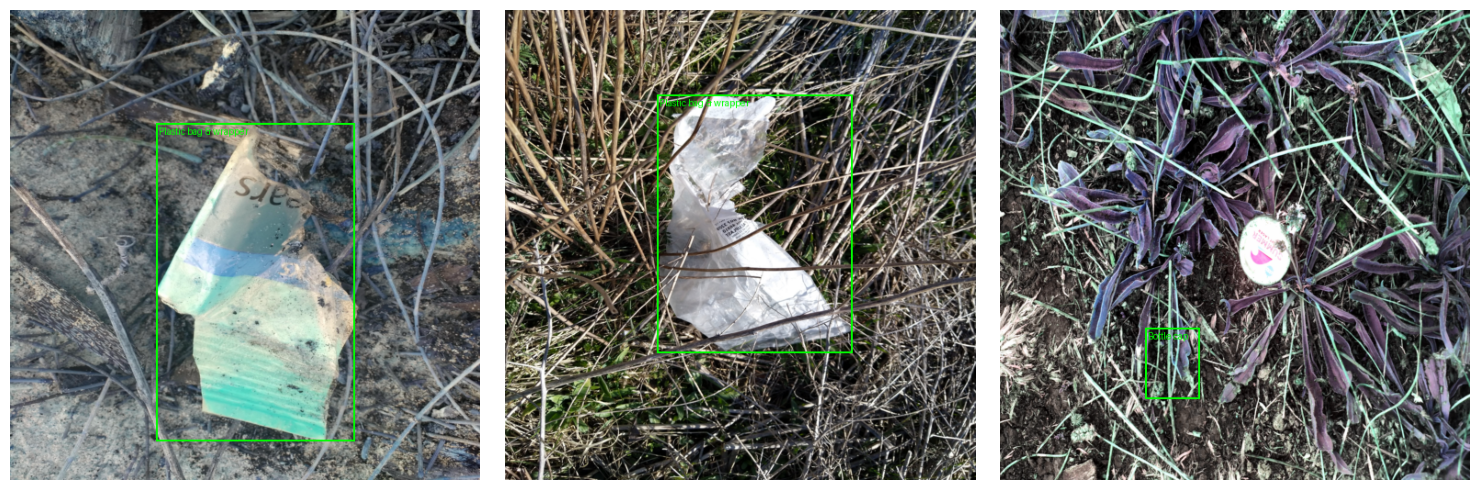

In [11]:
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = (img_tensor * std + mean).clamp(0, 1)
    return (img * 255).to(torch.uint8)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax in axes:
    img, target = train_ds[random.randrange(len(train_ds))]
    img_u8 = denormalize(img)
    boxes = target["boxes"]
    label_strs = [CLASSES[l - 1] for l in target["labels"].tolist()]
    drawn = draw_bounding_boxes(img_u8, boxes, labels=label_strs, colors="lime", width=2)
    ax.imshow(drawn.permute(1, 2, 0))
    ax.axis("off")
plt.tight_layout()
plt.show()


### Cell: build the Faster R-CNN model
**What:** loads `fasterrcnn_resnet50_fpn_v2` pretrained on COCO (80 everyday object classes —
none of them litter-specific, but the low-level visual features it already knows, edges,
textures, object-ness in general, are a strong head start), then swaps out only the final
classification layer (`box_predictor`) for a fresh one sized for our `NUM_CLASSES` (10 litter
classes + background). Everything before that layer keeps its pretrained weights and keeps
learning during fine-tuning.
**Why ResNet50-FPN-**v2** specifically (rather than the original ensemble-of-three from the last
notebook):** this is a single-model, genuinely-detecting project — no pseudo-boxes, no ensembling
hack needed — so the brief is different: use *one* strong, efficient detector well, rather than
three at once. The "v2" variant improves on the original FPN training recipe and is the best
accuracy-for-cost option torchvision ships for this backbone family.

In [12]:
model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params/1e6:.1f}M")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 179MB/s]


Trainable parameters: 43.1M


### Cell: training and validation loop
**What:** `train_one_epoch` runs one pass over the training set. In PyTorch's detection models,
calling `model(images, targets)` **while in `.train()` mode** doesn't return predictions at all —
it returns the four-part loss dictionary described in the architecture overview above
(`loss_classifier`, `loss_box_reg`, `loss_objectness`, `loss_rpn_box_reg`). We sum them into one
scalar and call `.backward()` as usual. `validate_loss` does the same forward pass on the
validation set but under `torch.no_grad()`, purely to track whether the model is still improving
on unseen data (and to pick the best checkpoint) — no weight updates happen there.
**Why here:** separated into two small functions so the actual training-run cell below stays
readable — it's just a loop calling these twice per epoch.

In [13]:
def train_one_epoch(model, optimizer, loader, device):
    model.train()
    running = 0.0
    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()
    return running / max(1, len(loader))


@torch.no_grad()
def validate_loss(model, loader, device):
    model.train()   # stays in train() mode so the model still returns a loss dict; no grad either way
    running = 0.0
    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        running += sum(loss_dict.values()).item()
    return running / max(1, len(loader))


### Cell: run the training
**What:** an SGD optimiser (the standard choice for fine-tuning torchvision detection models,
generally more stable than Adam for this architecture) with a step-decay learning-rate schedule,
looping for `NUM_EPOCHS`. The model state with the lowest validation loss is kept as the final
model (simple early-stopping-by-checkpoint), and saved to disk so this cell never has to be
re-run from scratch after a Colab disconnect.
**Why here:** this is the only cell that actually spends GPU time — everything above it was
preparation, everything below it evaluates or uses the result.

In [14]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, NUM_EPOCHS // 3), gamma=0.5)

os.makedirs("/content/checkpoints", exist_ok=True)
best_val, best_state = float("inf"), None

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    train_loss = train_one_epoch(model, optimizer, train_loader, DEVICE)
    val_loss = validate_loss(model, val_loader, DEVICE)
    scheduler.step()
    print(f"epoch {epoch+1}/{NUM_EPOCHS}  train_loss={train_loss:.4f}  "
          f"val_loss={val_loss:.4f}  ({time.time()-t0:.1f}s)")
    if val_loss < best_val:
        best_val, best_state = val_loss, copy.deepcopy(model.state_dict())
        torch.save(best_state, "/content/checkpoints/fasterrcnn_taco_best.pth")

model.load_state_dict(best_state)
print(f"Loaded best checkpoint (val_loss={best_val:.4f})")


epoch 1/12  train_loss=0.2648  val_loss=0.2444  (927.8s)
epoch 2/12  train_loss=0.2011  val_loss=0.2270  (934.8s)
epoch 3/12  train_loss=0.1789  val_loss=0.2279  (912.4s)
epoch 4/12  train_loss=0.1608  val_loss=0.2152  (893.2s)
epoch 5/12  train_loss=0.1381  val_loss=0.2063  (919.5s)
epoch 6/12  train_loss=0.1294  val_loss=0.2079  (857.5s)
epoch 7/12  train_loss=0.1220  val_loss=0.2101  (902.3s)
epoch 8/12  train_loss=0.1188  val_loss=0.2046  (922.2s)
epoch 9/12  train_loss=0.1106  val_loss=0.2077  (929.5s)
epoch 10/12  train_loss=0.1047  val_loss=0.2127  (914.0s)
epoch 11/12  train_loss=0.1023  val_loss=0.2181  (895.6s)
epoch 12/12  train_loss=0.1024  val_loss=0.2208  (964.5s)
Loaded best checkpoint (val_loss=0.2046)


### Cell: a single-image inference function
**What:** given a path to any photo, resizes it to `IMG_SIZE` (matching training), runs it
through the model in `.eval()` mode — which now returns actual **predictions** rather than a loss
dict: for each detected object, a box, a class label, and a confidence score, already
deduplicated by Faster R-CNN's built-in non-max suppression — then rescales the predicted boxes
back to the *original* image's pixel coordinates (since the model only ever saw the resized
version) and drops anything below `score_thresh`.
**Why rescaling matters:** if we skipped it, boxes would be correct only for the 512×512 resized
image and look randomly wrong when drawn on the original photo — this is one of the more common,
easy-to-miss bugs in detection pipelines.

In [15]:
@torch.no_grad()
def predict_image(model, image_path, device, resize_to=IMG_SIZE, score_thresh=0.3):
    img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = img.size
    img_r = img.resize((resize_to, resize_to))

    img_t = v2.functional.to_image(img_r)
    img_t = v2.functional.to_dtype(img_t, torch.float32, scale=True)
    img_t = v2.functional.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)

    model.eval()
    outputs = model([img_t.to(device)])[0]   # eval mode -> real predictions, not a loss dict

    boxes = outputs["boxes"].cpu().numpy()
    sx, sy = orig_w / resize_to, orig_h / resize_to
    boxes[:, [0, 2]] *= sx     # rescale x-coordinates back to the original image width
    boxes[:, [1, 3]] *= sy     # rescale y-coordinates back to the original image height

    labels = outputs["labels"].cpu().numpy()
    scores = outputs["scores"].cpu().numpy()

    keep = scores >= score_thresh
    return boxes[keep], labels[keep], scores[keep]


### Cell: visualise predictions on a few test photos
**What:** runs `predict_image` on some held-out test photos the model never trained on, and
draws the predicted boxes with their class name and confidence score.
**Why here:** numbers (mAP, in the next section) tell you *how well* the model is doing; looking
at actual pictures tells you *how* — e.g. whether it's missing small objects, confusing two
visually similar classes, or drawing loose/tight boxes — which is what actually goes into a
report's qualitative-results section.

/usr/local/lib/python3.13/dist-packages/torchvision/utils.py:352: UserWarning: boxes doesn't contain any box. No box was drawn
  warnings.warn("boxes doesn't contain any box. No box was drawn")


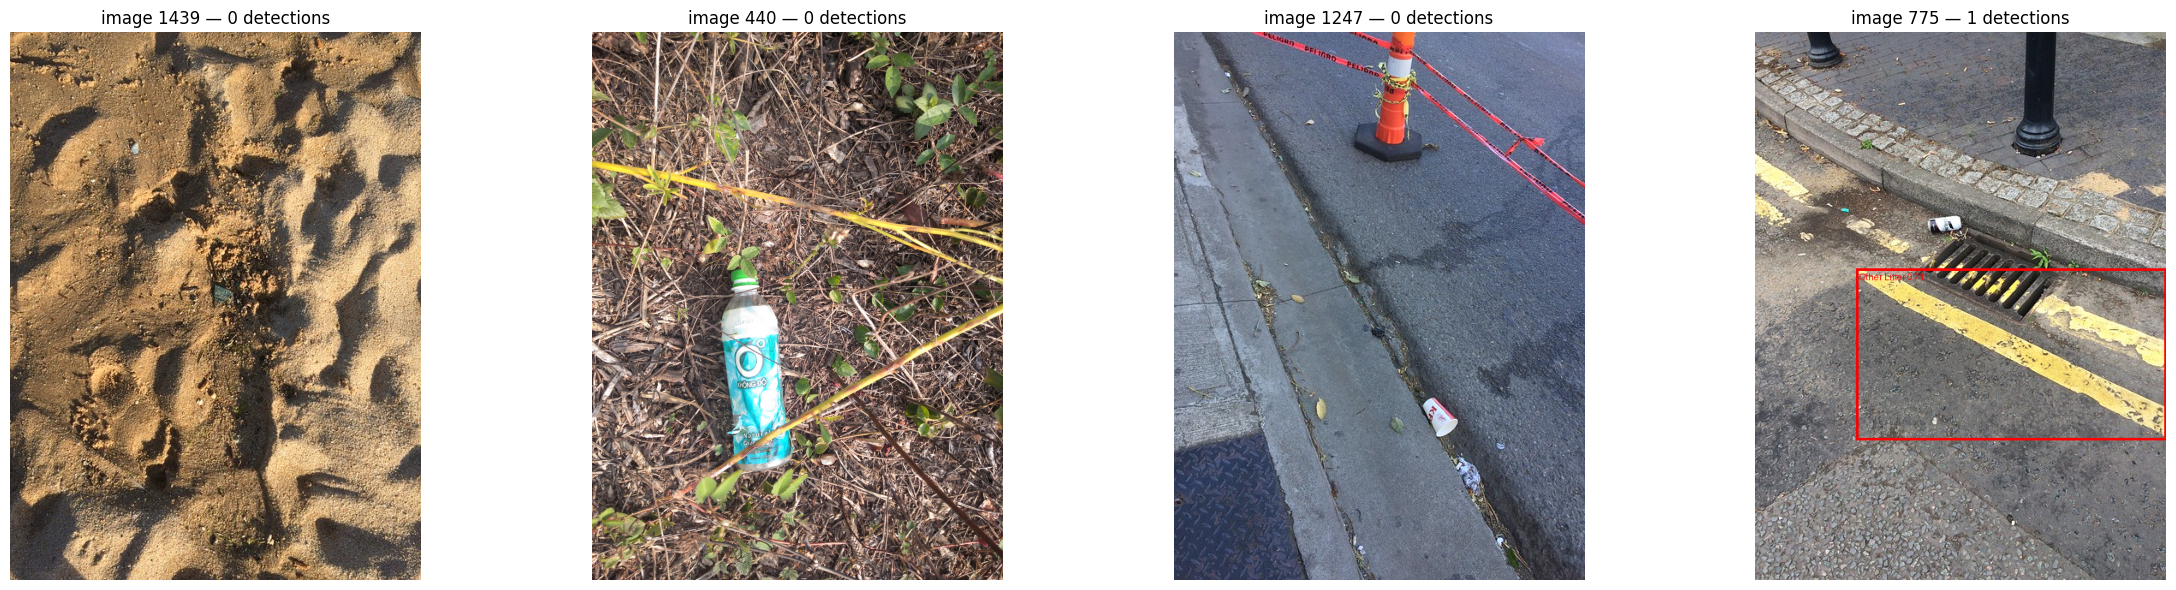

In [16]:
sample_test_ids = random.sample(test_ids, min(4, len(test_ids)))
fig, axes = plt.subplots(1, len(sample_test_ids), figsize=(6 * len(sample_test_ids), 6))
if len(sample_test_ids) == 1:
    axes = [axes]

for ax, img_id in zip(axes, sample_test_ids):
    path = os.path.join(IMG_DIR, f"{img_id}.jpg")
    boxes, labels, scores = predict_image(model, path, DEVICE, score_thresh=SCORE_THRESH_INFERENCE)

    img = Image.open(path).convert("RGB")
    img_t = v2.functional.to_image(img)
    label_strs = [f"{CLASSES[l-1]} {s:.2f}" for l, s in zip(labels, scores)]
    boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
    drawn = draw_bounding_boxes(img_t, boxes_t, labels=label_strs, colors="red", width=3)

    ax.imshow(drawn.permute(1, 2, 0))
    ax.set_title(f"image {img_id} — {len(boxes)} detections")
    ax.axis("off")
plt.tight_layout()
plt.show()


### Cell: build a ground-truth object for evaluation, in our reduced label space
**What:** `pycocotools`' evaluator (`COCOeval`) compares predictions against ground truth by
matching `category_id`s — but our predictions use our *reduced* 10-class label space, while the
original TACO annotations still use the *original* 60-category ids. This function builds a
fresh, in-memory COCO ground-truth object where every annotation's `category_id` has already been
remapped through `cat_id_to_label`, restricted to just the test-set images, so predictions and
ground truth speak the same "language" during evaluation.
**Why here:** this has to exist before the evaluation cell that uses it — it's the ground-truth
half of the comparison; the next cell produces the prediction half.

In [17]:
def build_remapped_coco_gt(coco, image_ids, cat_id_to_label, classes):
    images = coco.loadImgs(image_ids)
    categories = [{"id": i + 1, "name": c} for i, c in enumerate(classes)]

    annotations, ann_id = [], 1
    for img_id in image_ids:
        for a in coco.loadAnns(coco.getAnnIds(imgIds=img_id)):
            x, y, bw, bh = a["bbox"]
            if bw <= 1 or bh <= 1:
                continue
            annotations.append({
                "id": ann_id, "image_id": img_id,
                "category_id": cat_id_to_label[a["category_id"]],
                "bbox": [x, y, bw, bh], "area": bw * bh, "iscrowd": 0,
            })
            ann_id += 1

    coco_gt = COCO()
    coco_gt.dataset = {"images": images, "annotations": annotations, "categories": categories}
    coco_gt.createIndex()
    return coco_gt


### Cell: run the model over the test set and collect predictions in COCO's format
**What:** calls `predict_image` (the same function used for visualisation) on every test image,
and reformats each detection into the exact dictionary shape `pycocotools` expects:
`{image_id, category_id, bbox: [x, y, w, h], score}`. Uses a low `score_thresh=0.05` here (unlike
the stricter 0.5 used for visualisation) because mAP is computed across *all* confidence levels —
throwing away low-confidence detections early would make precision/recall look artificially
different from what the model can actually do.
**Why here:** this is the prediction half that pairs with `build_remapped_coco_gt` above; both
feed into `COCOeval` in the next cell.

In [18]:
def collect_predictions(model, coco, image_ids, img_dir, device, score_thresh=0.05):
    results = []
    for img_id in tqdm(image_ids, desc="Running inference on test set"):
        path = os.path.join(img_dir, f"{img_id}.jpg")
        boxes, labels, scores = predict_image(model, path, device, score_thresh=score_thresh)
        for box, label, score in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box
            results.append({
                "image_id": int(img_id), "category_id": int(label),
                "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                "score": float(score),
            })
    return results


### Cell: compute COCO mAP on the test set
**What:** builds the remapped ground truth, collects predictions, loads them into a
`COCOeval` object, and runs its standard three-step `evaluate() -> accumulate() -> summarize()`.
`summarize()` prints the full COCO metric suite — most importantly **AP@[.50:.95]** (average
precision averaged over 10 IoU thresholds from 0.5 to 0.95 — the strict, standard headline
number), **AP@.50** (a looser, "roughly the right box" number), and the same broken down by
object size (small/medium/large), since small litter items like bottle caps are typically the
hardest category for any detector.
**Why mAP and not plain accuracy:** accuracy answers "was the label right," which only makes
sense when there's exactly one object to label. mAP jointly scores *localisation* (was the box
in the right place, via IoU overlap with ground truth) *and* classification, and handles images
with a variable, unknown number of objects — which is exactly this dataset's shape.

In [19]:
coco_gt_test = build_remapped_coco_gt(coco, test_ids, cat_id_to_label, CLASSES)
predictions = collect_predictions(model, coco, test_ids, IMG_DIR, DEVICE, score_thresh=0.05)

if len(predictions) == 0:
    print("No predictions above threshold -- the model likely needs more training epochs.")
else:
    coco_dt = coco_gt_test.loadRes(predictions)
    coco_eval = COCOeval(coco_gt_test, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()


creating index...
index created!


Running inference on test set:   0%|          | 0/146 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.13s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.019
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.023
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.023
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.026
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.042
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.051
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.051
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

### Cell: per-category AP — which litter types the model actually learned
**What:** pulls the per-category precision array straight out of the already-`accumulate()`d
`coco_eval` object and averages it for each class, printing an AP@[.5:.95] value per class.
**Why here:** the single headline mAP number from the previous cell hides a lot — a model can
have a "good" overall mAP while being essentially blind to a rare class. This table is what
actually goes into a results/ablation section: it tells you (and a reviewer) exactly which
classes need more training data, and it's information the earlier single-label classification
project structurally couldn't produce, since it never had to separate multiple objects in the
first place.

In [20]:
precisions = coco_eval.eval["precision"]   # shape: [IoU thresholds, recall levels, classes, areas, maxDets]
for k, cname in enumerate(CLASSES):
    p = precisions[:, :, k, 0, -1]   # area='all', maxDets=100 (the last setting)
    p = p[p > -1]                     # -1 marks "no ground truth for this class at this setting"
    ap = p.mean() if p.size else float("nan")
    print(f"{cname:20s} AP@[.5:.95] = {ap:.3f}")


Plastic bag & wrapper AP@[.5:.95] = 0.028
Cigarette            AP@[.5:.95] = 0.000
Unlabeled litter     AP@[.5:.95] = 0.000
Bottle               AP@[.5:.95] = 0.090
Bottle cap           AP@[.5:.95] = 0.020
Can                  AP@[.5:.95] = 0.000
Other plastic        AP@[.5:.95] = 0.035
Carton               AP@[.5:.95] = 0.000
Cup                  AP@[.5:.95] = 0.015
Other Litter         AP@[.5:.95] = 0.002


## Limitations and honest framing

- **Dataset size.** TACO has roughly 1500 images total — small by object-detection standards
  (COCO itself has ~120,000). Expect noticeably lower mAP than you'd see on a mainstream detection
  benchmark; that's a property of the data, not a bug in the pipeline, and is worth stating
  proactively in a report rather than letting it look like an unexplained weak result.
- **Class imbalance survives the TACO-10 reduction.** Even after bucketing rare categories into
  "Other Litter," a handful of categories (plastic bags & wrappers, cigarettes, bottles) still
  dominate the annotation count — expect the per-class AP table above to show a long tail of
  weaker classes.
- **Link rot.** Because images are hosted on Flickr rather than bundled with the dataset, some
  fraction of `download_taco_images` calls will fail over time as individual photos or accounts
  are removed — this shrinks the effective dataset slightly on every fresh download.
- **Fixed resize (512×512).** Faster R-CNN can natively handle variable-sized/aspect-ratio images;
  this notebook resizes everything to a square purely to keep batching simple. If small objects
  (bottle caps, cigarette butts) are under-detected, a larger `IMG_SIZE` or `min_size`/`max_size`
  passed directly to the FPN backbone is the first thing to try.

## Natural extensions

- **Multi-backbone ensemble.** The earlier notebook's ensemble machinery (weighted fusion,
  OOD gate, confidence gate, decision fusion with agreement/ambiguity/reliability) can be layered
  on top of this real-detection setup too — run 2-3 Faster R-CNN backbone variants
  (`resnet50_fpn`, `resnet50_fpn_v2`, `mobilenet_v3_large_fpn`) here, take each one's per-box
  class distribution the same way, and fuse per matched box (matching by IoU across models rather
  than by whole image, since now there are multiple objects per image).
- **Deployment.** Wrap `predict_image` in a small Streamlit or Gradio app (upload a photo, see it
  annotated) for a live demo — this is a natural next step matching the earlier project's
  Streamlit deployment.